In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import interpolate
from sklearn import preprocessing as p

## Cleaning data

In [38]:
#importing data from Modulair MOD-00068
winddata = pd.read_csv('/content/MOD-00686-2-19data.csv').set_index('timestamp')
winddata.head()

,id,timestamp_local,sn,rh,temp,bin0,bin1,bin2,bin3,bin4,...,no2,o3,pm1_model_id,pm25_model_id,pm10_model_id,co_model_id,no_model_id,no2_model_id,o3_model_id,ws_scalar
timestamp,,,,,,,,,,,,,,,,,,,,,
2025-12-30T09:53:24Z,576509880,2025-12-30T04:53:24Z,MOD-00686,41.7,0.6,1.396,0.156,0.045,0.017,0.024,...,30.536,32.602,14331,14332,14333,14473.0,14498.0,14548.0,14523.0,3.23
2025-12-30T09:52:24Z,576509878,2025-12-30T04:52:24Z,MOD-00686,41.5,0.6,1.545,0.137,0.067,0.013,0.029,...,30.544,32.955,14331,14332,14333,14473.0,14498.0,14548.0,14523.0,4.65
2025-12-30T09:51:24Z,576509879,2025-12-30T04:51:24Z,MOD-00686,41.3,0.6,1.196,0.141,0.034,0.009,0.021,...,30.316,33.307,14331,14332,14333,14473.0,14498.0,14548.0,14523.0,4.27
2025-12-30T09:50:24Z,576509881,2025-12-30T04:50:24Z,MOD-00686,41.3,0.6,1.683,0.101,0.026,0.004,0.013,...,30.316,32.971,14331,14332,14333,14473.0,14498.0,14548.0,14523.0,3.94
2025-12-30T09:49:24Z,576508122,2025-12-30T04:49:24Z,MOD-00686,41.2,0.5,1.586,0.121,0.045,0.009,0.005,...,29.839,33.646,14331,14332,14333,14473.0,14498.0,14548.0,14523.0,4.91


In [39]:
#only columns of interest
COLS_TO_INCLUDE = ['timestamp_local','wd','ws']
winddata = winddata[COLS_TO_INCLUDE]

winddata.head()

,timestamp_local,wd,ws
timestamp,,,
2025-12-30T09:53:24Z,2025-12-30T04:53:24Z,305.8,2.87
2025-12-30T09:52:24Z,2025-12-30T04:52:24Z,338.7,3.92
2025-12-30T09:51:24Z,2025-12-30T04:51:24Z,318.8,3.29
2025-12-30T09:50:24Z,2025-12-30T04:50:24Z,346.1,3.26
2025-12-30T09:49:24Z,2025-12-30T04:49:24Z,324.4,4.05


In [40]:
#removing the UTC time
winddata = winddata.reset_index(drop = True)
winddata.head()

,timestamp_local,wd,ws
0,2025-12-30T04:53:24Z,305.8,2.87
1,2025-12-30T04:52:24Z,338.7,3.92
2,2025-12-30T04:51:24Z,318.8,3.29
3,2025-12-30T04:50:24Z,346.1,3.26
4,2025-12-30T04:49:24Z,324.4,4.05


In [41]:
#converting to datetime
winddata['timestamp_local'] = pd.to_datetime(winddata['timestamp_local'],
                                       format='%Y-%m-%dT%H:%M:%SZ',
                                       exact=False)
winddata.head()

,timestamp_local,wd,ws
0,2025-12-30 04:53:24,305.8,2.87
1,2025-12-30 04:52:24,338.7,3.92
2,2025-12-30 04:51:24,318.8,3.29
3,2025-12-30 04:50:24,346.1,3.26
4,2025-12-30 04:49:24,324.4,4.05


In [42]:
#taking hourly average of df. round to floor of the hour
winddata = winddata.groupby(winddata['timestamp_local'].dt.floor('h')).agg(wd = ('wd','mean'),
                                                                           ws = ('ws','mean')).reset_index()

winddata = winddata.round(decimals = 2)
winddata = winddata.dropna()
winddata

,timestamp_local,wd,ws
0,2025-04-25 10:00:00,0.00,0.00
1,2025-04-25 11:00:00,0.00,0.00
2,2025-04-25 13:00:00,186.90,4.24
3,2025-04-25 14:00:00,198.17,4.25
4,2025-04-25 15:00:00,194.57,5.15
...,...,...,...
5958,2025-12-30 00:00:00,307.76,6.65
5959,2025-12-30 01:00:00,309.76,7.05
5960,2025-12-30 02:00:00,316.61,7.41
5961,2025-12-30 03:00:00,299.93,8.19


In [43]:
ts = pd.read_csv('/content/MOD-000686_timeseries_hourly_scaled.csv')
ts.head()

,timestamp_local,co,no2,o3,no,bin0,bin1,bin2,bin3,bin4,bin5
0,2025-04-25 14:00:00,0.609759,0.558304,0.915602,0.041040,0.099365,0.027670,0.029347,0.036184,0.039024,0.032000
1,2025-04-25 15:00:00,0.523523,0.503337,0.852421,0.051897,0.090064,0.027968,0.030081,0.039474,0.039024,0.029333
2,2025-04-25 16:00:00,0.504615,0.543188,0.800844,0.049272,0.071801,0.026183,0.033015,0.046053,0.048780,0.037333
3,2025-04-25 17:00:00,0.461305,0.515705,0.777048,0.040802,0.058530,0.021720,0.027880,0.036184,0.036585,0.024000
4,2025-04-25 18:00:00,0.450995,0.589517,0.759114,0.039370,0.058190,0.024695,0.032282,0.046053,0.048780,0.042667


In [44]:
results = pd.read_csv('/content/686_factor_results.csv')
results.head()

,timestamp_local,Factor 1,Factor 2,Factor 3,Factor 4
0,2025-04-25 14:00:00,0.062044,0.007741,0.217094,0.011538
1,2025-04-25 15:00:00,0.054830,0.004849,0.201826,0.013078
2,2025-04-25 16:00:00,0.059158,0.001458,0.180766,0.017326
3,2025-04-25 17:00:00,0.055782,0.000000,0.174681,0.011953
4,2025-04-25 18:00:00,0.063088,0.000000,0.158269,0.017199


## Merging dataframes

In [45]:
data_1_2 = pd.merge(ts, results, on = 'timestamp_local', how = 'inner')
data_1_2

,timestamp_local,co,no2,o3,no,bin0,bin1,bin2,bin3,bin4,bin5,Factor 1,Factor 2,Factor 3,Factor 4
0,2025-04-25 14:00:00,0.609759,0.558304,0.915602,0.041040,0.099365,0.027670,0.029347,0.036184,0.039024,0.032000,0.062044,0.007741,0.217094,0.011538
1,2025-04-25 15:00:00,0.523523,0.503337,0.852421,0.051897,0.090064,0.027968,0.030081,0.039474,0.039024,0.029333,0.054830,0.004849,0.201826,0.013078
2,2025-04-25 16:00:00,0.504615,0.543188,0.800844,0.049272,0.071801,0.026183,0.033015,0.046053,0.048780,0.037333,0.059158,0.001458,0.180766,0.017326
3,2025-04-25 17:00:00,0.461305,0.515705,0.777048,0.040802,0.058530,0.021720,0.027880,0.036184,0.036585,0.024000,0.055782,0.000000,0.174681,0.011953
4,2025-04-25 18:00:00,0.450995,0.589517,0.759114,0.039370,0.058190,0.024695,0.032282,0.046053,0.048780,0.042667,0.063088,0.000000,0.158269,0.017199
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5892,2025-12-30 00:00:00,0.356654,0.545347,0.386004,0.023980,0.026429,0.008926,0.006603,0.006579,0.004878,0.005333,0.061642,0.001354,0.052948,0.000000
5893,2025-12-30 01:00:00,0.354775,0.554967,0.386238,0.025531,0.024841,0.007736,0.005869,0.006579,0.004878,0.002667,0.062626,0.000790,0.051523,0.000000
5894,2025-12-30 02:00:00,0.352962,0.553985,0.399836,0.023980,0.020077,0.005951,0.004402,0.003289,0.004878,0.005333,0.062358,0.000000,0.055324,0.000000
5895,2025-12-30 03:00:00,0.353444,0.560660,0.414254,0.020401,0.017015,0.002975,0.002201,0.003289,0.002439,0.002667,0.062872,0.000000,0.058211,0.000000


In [46]:
data_1_2['timestamp_local'] = pd.to_datetime(data_1_2['timestamp_local'])

In [47]:
data = pd.merge(data_1_2, winddata, on = 'timestamp_local', how = 'inner')
data

,timestamp_local,co,no2,o3,no,bin0,bin1,bin2,bin3,bin4,bin5,Factor 1,Factor 2,Factor 3,Factor 4,wd,ws
0,2025-04-25 14:00:00,0.609759,0.558304,0.915602,0.041040,0.099365,0.027670,0.029347,0.036184,0.039024,0.032000,0.062044,0.007741,0.217094,0.011538,198.17,4.25
1,2025-04-25 15:00:00,0.523523,0.503337,0.852421,0.051897,0.090064,0.027968,0.030081,0.039474,0.039024,0.029333,0.054830,0.004849,0.201826,0.013078,194.57,5.15
2,2025-04-25 16:00:00,0.504615,0.543188,0.800844,0.049272,0.071801,0.026183,0.033015,0.046053,0.048780,0.037333,0.059158,0.001458,0.180766,0.017326,194.63,4.06
3,2025-04-25 17:00:00,0.461305,0.515705,0.777048,0.040802,0.058530,0.021720,0.027880,0.036184,0.036585,0.024000,0.055782,0.000000,0.174681,0.011953,196.33,6.40
4,2025-04-25 18:00:00,0.450995,0.589517,0.759114,0.039370,0.058190,0.024695,0.032282,0.046053,0.048780,0.042667,0.063088,0.000000,0.158269,0.017199,195.05,6.70
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5892,2025-12-30 00:00:00,0.356654,0.545347,0.386004,0.023980,0.026429,0.008926,0.006603,0.006579,0.004878,0.005333,0.061642,0.001354,0.052948,0.000000,307.76,6.65
5893,2025-12-30 01:00:00,0.354775,0.554967,0.386238,0.025531,0.024841,0.007736,0.005869,0.006579,0.004878,0.002667,0.062626,0.000790,0.051523,0.000000,309.76,7.05
5894,2025-12-30 02:00:00,0.352962,0.553985,0.399836,0.023980,0.020077,0.005951,0.004402,0.003289,0.004878,0.005333,0.062358,0.000000,0.055324,0.000000,316.61,7.41
5895,2025-12-30 03:00:00,0.353444,0.560660,0.414254,0.020401,0.017015,0.002975,0.002201,0.003289,0.002439,0.002667,0.062872,0.000000,0.058211,0.000000,299.93,8.19


## Plots

In [48]:
wd_rad = np.radians(np.array(data['wd'])) #deg to rad
ws = np.array(data['ws']) #m/s
Factor1 = np.array(data['Factor 1'])
Factor2 = np.array(data['Factor 2'])
Factor3 = np.array(data['Factor 3'])
Factor4 = np.array(data['Factor 4'])

In [49]:
WD, WS = np.meshgrid(np.linspace(0, 2*np.pi, 36), np.linspace(min(ws), max(ws), 16 ))
Z1 = interpolate.griddata((wd_rad, ws), Factor1, (WD, WS), method='linear')
Z2 = interpolate.griddata((wd_rad, ws), Factor2, (WD, WS), method='linear')
Z3 = interpolate.griddata((wd_rad, ws), Factor3, (WD, WS), method='linear')
Z4 = interpolate.griddata((wd_rad, ws), Factor4, (WD, WS), method='linear')

Z1 = np.nan_to_num(Z1, nan=1e-3)
Z2 = np.nan_to_num(Z2, nan=1e-3)
Z3 = np.nan_to_num(Z3, nan=1e-3)
Z4 = np.nan_to_num(Z4, nan=1e-3)

In [50]:
maxima = [np.max(i) for i in [Z1,Z2,Z3,Z4]]
maxima

[np.float64(0.07783189540213828),
 np.float64(0.1242267285452186),
 np.float64(0.1937486884201886),
 np.float64(0.36170298662738515)]

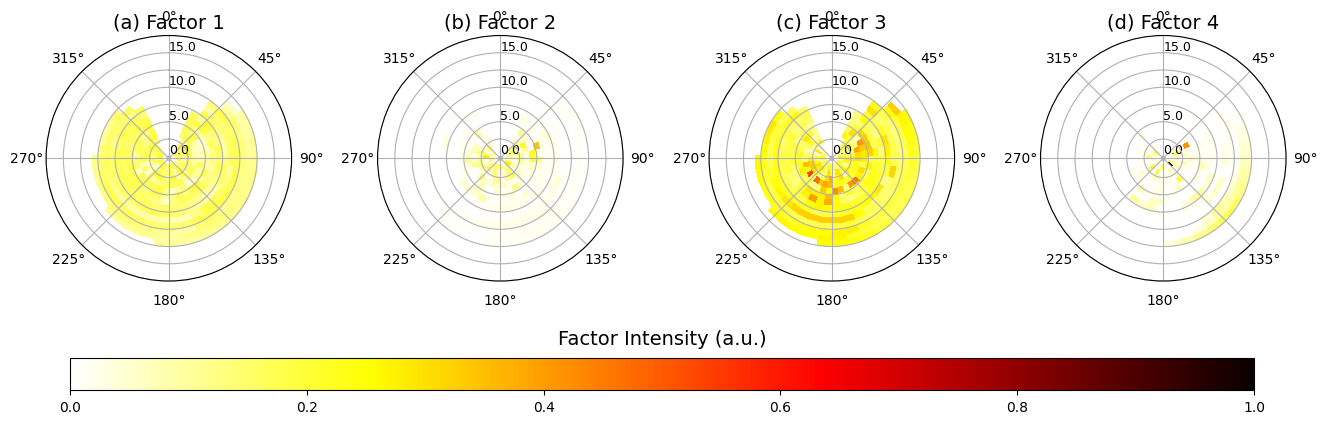

In [52]:
# set up the matplotlib figure
fig, ax = plt.subplots(nrows=1, ncols=4, figsize=(16, 16), subplot_kw={'projection': 'polar'})
plt.subplots_adjust(wspace=0.35)
cmap = plt.get_cmap('hot_r')
cmap.set_under('none')

#change set-up to compass bearings
for i in range(4):
    ax[i].set_theta_zero_location('N')
    ax[i].set_theta_direction(-1)

#label
ax[0].set_title('(a) Factor 1',fontsize=14)
ax[1].set_title('(b) Factor 2',fontsize=14)
ax[2].set_title('(c) Factor 3',fontsize=14)
ax[3].set_title('(d) Factor 4',fontsize=14)

#plot
img1 = ax[0].pcolormesh(WD, WS, Z1, cmap=cmap, vmax = np.max(Z4))
img2 = ax[1].pcolormesh(WD, WS, Z2, cmap=cmap, vmax = np.max(Z4))
img3 = ax[2].pcolormesh(WD, WS, Z3, cmap=cmap, vmax = np.max(Z4))
img4 = ax[3].pcolormesh(WD, WS, Z4, cmap=cmap, vmax = np.max(Z4))

#label radial ticks
for i in range(4):
    ax[i].tick_params(axis='y', which='major', labelsize=9)
    ax[i].set_rticks([0,2.5,5,7.5,10,12.5,15,17.5])
    ax[i].set_rlabel_position(0)
    ax[i].set_yticklabels(['0.0','','5.0','','10.0','','15.0',''])

#set colorbar
cbar_ax = fig.add_axes([0.14, 0.35, 0.74, 0.02])
cbar = fig.colorbar(img4, cax=cbar_ax, orientation='horizontal')
cbar.set_ticks(list(np.linspace(0, np.max(Z4), 6)))
cbar.set_ticklabels([0.0,0.2,0.4,0.6,0.8,1.0])
cbar.set_label('Factor Intensity (a.u.)', labelpad = 10, fontsize = 14)
cbar.ax.xaxis.set_label_position('top')

fig.savefig('/content/windrose_MOD-000686.png')